<a href="https://colab.research.google.com/github/yewonhn/My-AI-Lab/blob/main/5%EC%A3%BC%EC%B0%A8/05_Wine_CL_RE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/wine.csv")
df

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [2]:
X = df.drop('Wine', axis=1)
y = df['Wine']

###분류

와인의 종류를 분류 - 다중 분류 <br>
클래스 1,2,3을 숫자적 관계로 해석할 여지가 있으므로, 원핫인코딩을 통해 관계를 끊어줘야 함.

In [3]:
from tensorflow.keras.utils import to_categorical

# 1. 정답 데이터를 0부터 시작하게 맞춘 후 원-핫 인코딩 (1,2,3 -> 0,1,2 -> 원-핫)
y_encoded = to_categorical(df['Wine'] - 1)
X = df.drop('Wine', axis=1)

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 학습,훈련 데이터 분류 및 스케일링

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 모델 만들기
model = Sequential([
    Dense(64, activation='relu', input_shape=(13,)),
    Dense(32, activation='relu'),
    # 다중 분류 : 종류가 3개이므로 노드 3개, 활성화 함수는 softmax!@!    (2개면? 시그모이드)
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    # 다중 분류 : loss는 categorical_crossentropy
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
from tensorflow.keras.utils import to_categorical

# 정답지도 원-핫 인코딩으로 변환(와인이 1,2,3번이므로 1을 빼서 0,1,2로 맞춤)
y_encoded = to_categorical(df['Wine'] - 1)

# 다시 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [7]:
# 학습 시작
model.fit(X_train, y_train, epochs=50, batch_size=10, validation_split=0.2)

# 평가
loss, acc = model.evaluate(X_test, y_test)
print(f"테스트 정확도: {acc:.4f}")

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.2832 - loss: 45.5542 - val_accuracy: 0.5172 - val_loss: 12.2254
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3717 - loss: 7.9552 - val_accuracy: 0.3103 - val_loss: 6.4461
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3009 - loss: 4.0626 - val_accuracy: 0.5172 - val_loss: 1.1628
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5310 - loss: 1.5418 - val_accuracy: 0.5517 - val_loss: 0.8550
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4602 - loss: 1.0171 - val_accuracy: 0.7586 - val_loss: 0.6312
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5929 - loss: 0.8058 - val_accuracy: 0.5862 - val_loss: 0.8213
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6814 - loss: 0.6630 - val_accuracy: 0.6897 - val_loss: 0.6907
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6372 - loss: 0.7309 - val_accuracy: 0.7931 - val_lo

### 회귀
알코올 도수(Alcohol)가 몇 도인지 예측하는 모델 <br>
정답 y = Alcohol

In [16]:
y_reg = df['Alcohol']
X_reg = df.drop('Alcohol',axis=1)

# 데이터 분할
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 스케일링
scaler_wine = StandardScaler()
X_train_scaled = scaler_wine.fit_transform(X_train)
X_test_scaled = scaler_wine.transform(X_test)

In [27]:
from tensorflow.keras.layers import Input, Dense # Input을 불러와야 합니다!
from tensorflow.keras.models import Sequential

# 모델 설계
model_wine_reg = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)  # 알코올 도수 숫자 하나만 출력.
])

model_wine_reg.compile(
    optimizer='adam',
    loss='mse',      # 오차의 제곱
    metrics=['mae']  # 실제 도수와 몇 도나 차이 나는지 확인 (사람이 확인하기 좋은..)
)

# 학습 시작
history_wine_reg = model_wine_reg.fit(X_train_scaled, y_train_reg, epochs=100, validation_split=0.2, verbose=0)

In [28]:
loss, mae = model_wine_reg.evaluate(X_test_scaled, y_test_reg)

print("-" * 30)
print(f"종합 손실(MSE): {loss:.4f}")
print(f"평균 절대 오차(MAE): {mae:.4f}")
print(f"해석: 모델은 와인 도수를 평균 {mae:.2f}도 정도 틀립니다.")
print("-" * 30)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 2.6598 - mae: 1.2620
------------------------------
종합 손실(MSE): 2.6598
평균 절대 오차(MAE): 1.2620
해석: 모델은 와인 도수를 평균 1.26도 정도 틀립니다.
------------------------------


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


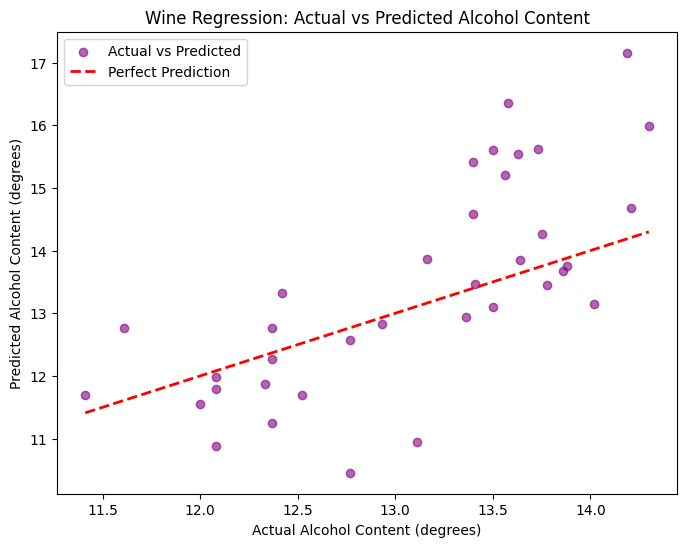

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# 테스트 데이터로 예측값 생성
y_pred_reg = model_wine_reg.predict(X_test_reg)

# 산점도 그래프 그리기
plt.figure(figsize=(8, 6))

# 점 찍기: 실제값 vs 예측값
plt.scatter(y_test_reg, y_pred_reg, alpha=0.6, color='purple', label='Actual vs Predicted')

# 완벽하게 맞혔을 때의 기준선 (대각선: 빨간 점선)
# x축과 y축의 범위를 실제 도수의 최솟값~최댓값으로 설정
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2, label='Perfect Prediction')

# 라벨 및 스타일 설정
plt.xlabel('Actual Alcohol Content (degrees)')
plt.ylabel('Predicted Alcohol Content (degrees)')
plt.title('Wine Regression: Actual vs Predicted Alcohol Content')
plt.legend()
plt.show()

학습 곡선

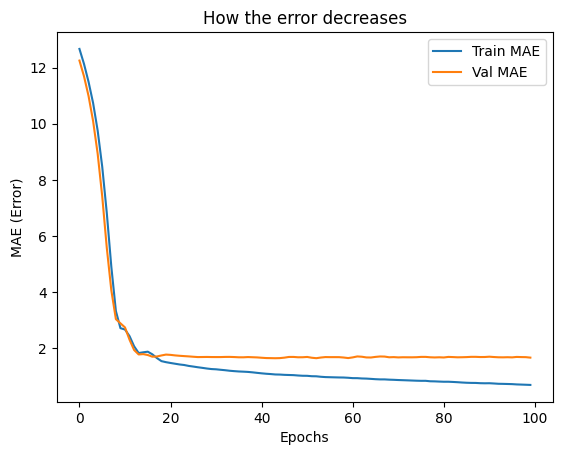

In [29]:
import matplotlib.pyplot as plt

plt.plot(history_wine_reg.history['mae'], label='Train MAE')
plt.plot(history_wine_reg.history['val_mae'], label='Val MAE')
plt.title('How the error decreases')
plt.ylabel('MAE (Error)')
plt.xlabel('Epochs')
plt.legend()
plt.show()